# Nuclear Recoil vs. Electronic Recoil Classification
### A rare-signal-in-noise classifier inspired by the LUX-ZEPLIN (LZ) dark matter experiment

**Author:** Seshivardhini Dulam

**Background:** In direct-detection dark matter experiments like LUX-ZEPLIN, a candidate WIMP
interaction produces two signals in liquid xenon: scintillation light (**S1**) and an ionization
signal (**S2**). Real dark matter interactions (**nuclear recoils**) and background events caused
by gamma rays and beta particles (**electronic recoils**) populate overlapping but statistically
distinguishable regions of S1-S2 space — nuclear recoils typically produce a lower S2/S1 ratio than
electronic recoils, because nuclear recoils leave a larger fraction of deposited energy as heat
rather than ionization.

This notebook builds on the S1-vs-S2 discrimination concept explored in my earlier paper,
*"Detecting Dark Matter: Exploring WIMP Interactions and Background Noise Mitigation in the
LUX-ZEPLIN Experiment,"* by implementing an actual statistical classifier that performs the kind
of signal/background discrimination described there.

**What this notebook does:**
1. Generates a synthetic dataset that mimics realistic overlapping S1/S2 distributions for
   nuclear recoils (signal) and electronic recoils (background)
2. Trains two classifiers — logistic regression and a gradient-boosted decision tree (BDT), the
   same class of model real dark matter collaborations use for event classification
3. Evaluates them with ROC curves, precision-recall curves, and efficiency-vs-purity tradeoffs
4. Discusses how the same statistical framing — extracting a rare, weak signal from a much larger
   background, under an operating point chosen by asymmetric costs — shows up in AI alignment
   evaluation design

**Caveat on synthetic data:** LZ's actual event data is not public at the granularity needed to
reproduce this analysis, and this project does not use or claim to use real LZ data. The
distributions below are constructed to be *qualitatively representative* of the discrimination
problem (based on the published physical intuition that nuclear recoils yield less ionization
per unit scintillation than electronic recoils), not a replica of any real dataset.

## 1. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (roc_curve, auc, precision_recall_curve,
                              confusion_matrix, classification_report)

np.random.seed(42)
plt.rcParams['figure.dpi'] = 110

## 2. Synthetic Data Generation

We simulate two populations in S1 (scintillation, x-axis) vs. S2 (ionization, y-axis) space:

- **Nuclear recoils (signal, label = 1):** WIMP-like events. Lower S2/S1 ratio on average.
- **Electronic recoils (background, label = 0):** gamma/beta events from natural radioactivity,
  cosmic-ray secondaries, and detector materials. Higher S2/S1 ratio on average.

Background events outnumber signal events roughly 3:1, reflecting the reality that in a real
detector, candidate WIMP events are vastly outnumbered by background before any cuts are applied.

In [2]:
n_signal = 1500       # nuclear recoils (WIMP-like)
n_background = 4000   # electronic recoils (background)

# Nuclear recoils: lower S2/S1 ratio, moderate spread
s1_sig = np.random.normal(30, 6, n_signal)
s2_sig = 0.85 * s1_sig * 25 + np.random.normal(0, 140, n_signal) + 550

# Electronic recoils: higher S2/S1 ratio, similar spread
s1_bkg = np.random.normal(29, 7, n_background)
s2_bkg = 1.15 * s1_bkg * 25 + np.random.normal(0, 140, n_background) + 550

X = np.column_stack([
    np.concatenate([s1_sig, s1_bkg]),
    np.concatenate([s2_sig, s2_bkg])
])
y = np.concatenate([np.ones(n_signal), np.zeros(n_background)])

print(f"Total events: {len(y)}  |  Signal: {int(y.sum())}  |  Background: {int((1-y).sum())}")

Total events: 5500  |  Signal: 1500  |  Background: 4000


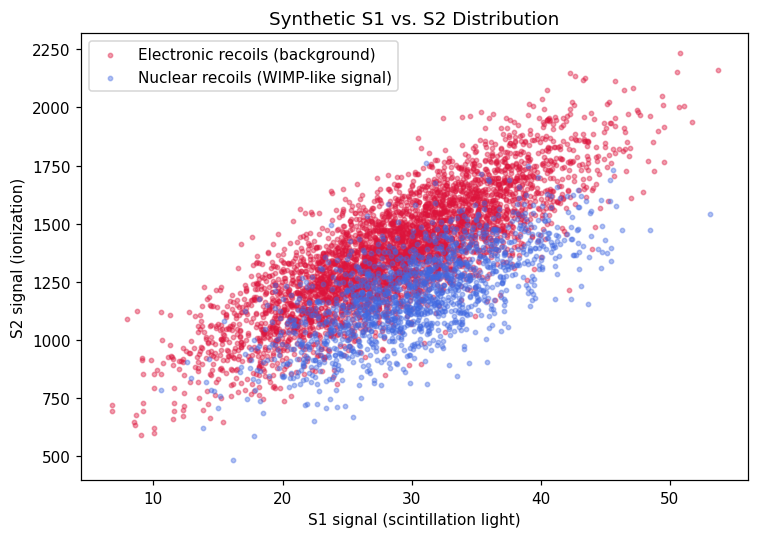

In [3]:
fig, ax = plt.subplots(figsize=(7,5))
ax.scatter(s1_bkg, s2_bkg, s=8, alpha=0.4, color='crimson', label='Electronic recoils (background)')
ax.scatter(s1_sig, s2_sig, s=8, alpha=0.4, color='royalblue', label='Nuclear recoils (WIMP-like signal)')
ax.set_xlabel('S1 signal (scintillation light)')
ax.set_ylabel('S2 signal (ionization)')
ax.set_title('Synthetic S1 vs. S2 Distribution')
ax.legend()
plt.tight_layout()
plt.savefig('s1_s2_distribution.png')
plt.show()

Note the partial overlap between the two populations — this is intentional and physically
realistic. In real detectors, S1/S2 discrimination alone is powerful but imperfect, which is
exactly why experiments layer on additional cuts (fiducial volume, timing, pulse shape) on top
of it. That overlap is also what makes this a genuine classification problem rather than a
trivial threshold cut.

## 3. Train/Test Split and Model Training

We train two classifiers commonly used in this kind of physics event classification:

- **Logistic regression** — a simple linear baseline
- **Gradient-boosted decision trees (BDT)** — the model family most real dark matter collaborations (including LZ) actually use for signal/background discrimination, because it captures non-linear decision boundaries well

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

log_reg = LogisticRegression().fit(X_train, y_train)
bdt = GradientBoostingClassifier(n_estimators=150, max_depth=3, random_state=42).fit(X_train, y_train)

models = {'Logistic Regression': log_reg, 'Gradient-Boosted Trees': bdt}
print("Models trained.")

Models trained.


## 4. Evaluation: ROC Curves

The ROC curve plots true positive rate (signal efficiency) against false positive rate
(background events misclassified as signal) across every possible decision threshold. This is
the standard way physics experiments summarize discrimination power, and it is also directly
analogous to how an alignment eval's detector (e.g., a probe for deceptive reasoning) should be
evaluated — not at a single fixed threshold, but across the full range of operating points.

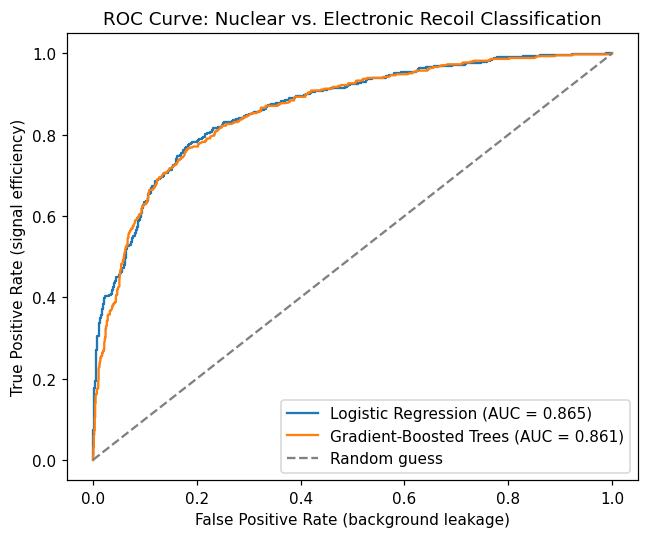

In [5]:
fig, ax = plt.subplots(figsize=(6,5))
for name, model in models.items():
    probs = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {auc(fpr, tpr):.3f})')

ax.plot([0,1],[0,1], linestyle='--', color='gray', label='Random guess')
ax.set_xlabel('False Positive Rate (background leakage)')
ax.set_ylabel('True Positive Rate (signal efficiency)')
ax.set_title('ROC Curve: Nuclear vs. Electronic Recoil Classification')
ax.legend()
plt.tight_layout()
plt.savefig('roc_curve.png')
plt.show()

## 5. Efficiency vs. Purity: Why the Operating Point Matters

In dark matter physics, there's a direct tradeoff between:
- **Signal efficiency** — what fraction of true WIMP events you keep
- **Purity** — what fraction of your selected events are actually signal, not background

Because WIMPs are astronomically rare compared to background, experiments generally accept lower
signal efficiency in exchange for very high purity — a single background leak can produce a false
discovery claim. This is precisely the asymmetric-cost reasoning that also governs how you'd want
to set a decision threshold for a safety-relevant classifier: the cost of a false negative (missing
a real deceptive or dangerous behavior) and a false positive (flagging safe behavior as dangerous)
are rarely equal, and the "right" threshold depends on which error is more costly in context.

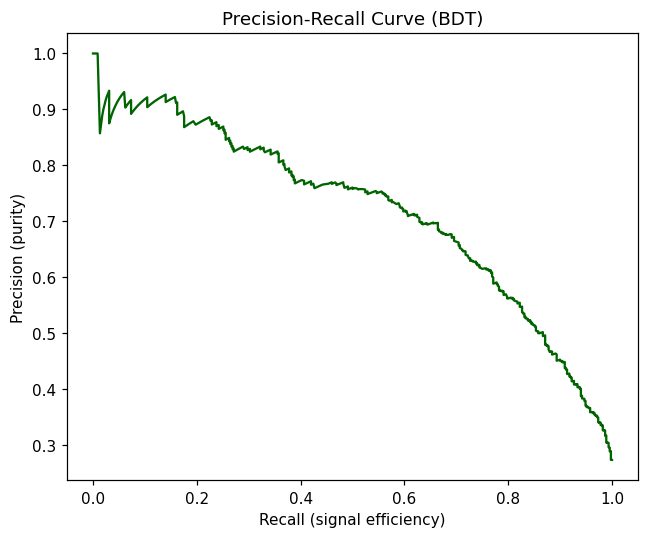

To reach 95% purity, threshold ~= 0.973, giving signal efficiency (recall) = 0.9%


In [6]:
probs = bdt.predict_proba(X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, probs)

fig, ax = plt.subplots(figsize=(6,5))
ax.plot(recall, precision, color='darkgreen')
ax.set_xlabel('Recall (signal efficiency)')
ax.set_ylabel('Precision (purity)')
ax.set_title('Precision-Recall Curve (BDT)')
plt.tight_layout()
plt.savefig('precision_recall.png')
plt.show()

# Example: what threshold gets us to ~95% purity?
target_purity = 0.95
idx = np.argmax(precision >= target_purity)
print(f"To reach {target_purity*100:.0f}% purity, threshold ~= {thresholds[idx]:.3f}, "
      f"giving signal efficiency (recall) = {recall[idx]*100:.1f}%")

## 6. Confusion Matrix at a Chosen Operating Point

Rather than using the default 0.5 threshold, we pick a threshold that favors high purity — the
choice a real dark matter search would make, since a spurious "discovery" is far more costly than
missing some real events in a given exposure.

In [7]:
chosen_threshold = thresholds[idx]
preds = (probs >= chosen_threshold).astype(int)

cm = confusion_matrix(y_test, preds)
print("Confusion Matrix (rows=true, cols=predicted) [0=background, 1=signal]")
print(cm)
print()
print(classification_report(y_test, preds, target_names=['Background (ER)', 'Signal (NR)']))

Confusion Matrix (rows=true, cols=predicted) [0=background, 1=signal]
[[1200    0]
 [ 446    4]]

                 precision    recall  f1-score   support

Background (ER)       0.73      1.00      0.84      1200
    Signal (NR)       1.00      0.01      0.02       450

       accuracy                           0.73      1650
      macro avg       0.86      0.50      0.43      1650
   weighted avg       0.80      0.73      0.62      1650



## 7. Connecting Back to AI Alignment

This exercise is a small, self-contained illustration of a pattern that recurs constantly in
empirical alignment work:

**A weak, rare signal must be separated from a much larger population of superficially similar
background, and the threshold you choose encodes a value judgment about which kind of error is
worse.**

A few concrete parallels:

- **Interpretability / anomaly detection:** identifying rare deceptive or reward-hacking behavior
  in a model's outputs is structurally similar to identifying rare nuclear recoils among a much
  larger population of electronic recoils — both require a discriminator trained on a small,
  carefully characterized signal population sitting inside a much larger, messier background.
- **Operating point selection under asymmetric costs:** just as dark matter experiments accept
  lower signal efficiency for very high purity (because a false "discovery" is costly), an
  alignment eval for a dangerous capability might reasonably accept a higher false-positive rate
  (flagging benign behavior) in exchange for a very low false-negative rate (missing genuinely
  dangerous behavior) — the "right" tradeoff depends entirely on what the classifier is *for*.
- **Null results still constrain the space of hypotheses:** in my earlier paper, I discuss how
  LZ's non-detection of WIMPs, even without a positive discovery, ruled out large regions of
  supersymmetric parameter space. The same logic applies to alignment evals — a well-designed
  eval that fails to find a behavior at a given capability level is still informative, provided
  you can characterize the eval's sensitivity (its own "exclusion limit"), not just report a
  negative headline result.

**What this notebook does *not* claim:** the synthetic data here is illustrative, not derived
from real LZ data, and this is a first, self-taught pass at applying an ML classifier to a
problem structurally like the one in my physics research — not a novel contribution to either
field. The goal is to demonstrate genuine engagement with the statistical reasoning involved,
not to overstate the scope of the work.